**Trading Algorithm Script:** 

This script follows the DataCamp tutorial on visualising stock returns as time series data using the AlphaVantage API. It covers some of the most common financial analyses, like moving windows and volatility calcualtion using the Python pandas package. 

This script also develops a simple momentum strategy, backtests it, and optimises it to aid its performance in the future. 

In [ ]:
# Installing the necessary packages:

%pip install pandas 
%pip install requests 
%pip install datetime 
%pip install pandas_datareader 
%pip install distutils 
%pip install beautifulsoup
%pip install bs4 
%pip install alphavantage
%pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas_datareader as pdr 
import datetime
import requests as re 
from alpha_vantage.timeseries import TimeSeries
from bs4 import BeautifulSoup 
import pandas as pd 
import io 
import numpy as np
import matplotlib.pyplot as plt

In [5]:
with open("API_key_3.txt") as file: 
    API_key = file.read()

In [15]:
API_key = API_key.strip()
API_key

'AUO83FRIK6KZ5KMH'

In [10]:
ts1 = TimeSeries(key = API_key)

In [19]:
# Getting intraday stock data of Apple: 
ts1.get_monthly("AAPL")

({'2026-03-17': {'1. open': '262.4100',
   '2. high': '266.5300',
   '3. low': '249.5200',
   '4. close': '254.2300',
   '5. volume': '448144916'},
  '2026-02-27': {'1. open': '260.0300',
   '2. high': '280.9050',
   '3. low': '255.4500',
   '4. close': '264.1800',
   '5. volume': '988325816'},
  '2026-01-30': {'1. open': '272.2550',
   '2. high': '277.8400',
   '3. low': '243.4200',
   '4. close': '259.4800',
   '5. volume': '1036170325'},
  '2025-12-31': {'1. open': '278.0100',
   '2. high': '288.6200',
   '3. low': '266.9500',
   '4. close': '271.8600',
   '5. volume': '922283649'},
  '2025-11-28': {'1. open': '270.4200',
   '2. high': '280.3800',
   '3. low': '265.3200',
   '4. close': '278.8500',
   '5. volume': '876481453'},
  '2025-10-31': {'1. open': '255.0400',
   '2. high': '277.3200',
   '3. low': '244.0000',
   '4. close': '270.3700',
   '5. volume': '1097142365'},
  '2025-09-30': {'1. open': '229.2500',
   '2. high': '257.6000',
   '3. low': '225.9500',
   '4. close': '254

In [32]:
#Getting intraday Apple stock data using requests package

url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=AAPL&apikey=' + str(API_key) + "&datatype=csv"
r = re.get(url).content 
aapl = pd.read_csv(io.StringIO(r.decode("utf-8")))
print(aapl)

     timestamp     open      high       low   close    volume
0   2026-03-17  252.820  255.1299  252.1800  254.23  32342249
1   2026-03-16  252.105  253.8850  249.8800  252.82  32074209
2   2026-03-13  255.480  256.3300  249.5200  250.12  36929988
3   2026-03-12  258.660  258.9500  254.1800  255.76  40794020
4   2026-03-11  261.090  262.1300  259.5500  260.81  26218927
..         ...      ...       ...       ...     ...       ...
95  2025-10-28  268.985  269.8900  268.1500  269.00  41534759
96  2025-10-27  264.880  269.1200  264.6501  268.81  44888152
97  2025-10-24  261.190  264.1300  259.1800  262.82  38253717
98  2025-10-23  259.940  260.6200  258.0101  259.58  32754941
99  2025-10-22  262.650  262.8500  255.4300  258.45  45015254

[100 rows x 6 columns]


In [33]:
print(aapl.head(10))
print(aapl.tail(10))

    timestamp     open      high       low   close    volume
0  2026-03-17  252.820  255.1299  252.1800  254.23  32342249
1  2026-03-16  252.105  253.8850  249.8800  252.82  32074209
2  2026-03-13  255.480  256.3300  249.5200  250.12  36929988
3  2026-03-12  258.660  258.9500  254.1800  255.76  40794020
4  2026-03-11  261.090  262.1300  259.5500  260.81  26218927
5  2026-03-10  257.645  262.4800  256.9500  260.83  30590765
6  2026-03-09  255.690  261.1500  253.6805  259.88  38218533
7  2026-03-06  258.630  258.7700  254.3700  257.46  41120042
8  2026-03-05  260.790  261.5550  257.2500  260.29  49658626
9  2026-03-04  264.650  266.1500  261.4200  262.52  39803119
     timestamp     open     high       low   close    volume
90  2025-11-04  268.325  271.486  267.6150  270.04  49274846
91  2025-11-03  270.420  270.850  266.2500  269.05  50194583
92  2025-10-31  276.990  277.320  269.1600  270.37  86167123
93  2025-10-30  271.990  274.140  268.4800  271.40  69886534
94  2025-10-29  269.275 

In [21]:
aapl.to_csv('AAPLstockdata.csv')

In [34]:
# Checking columns of the data 
print(aapl.columns)

# Checking rows of the data 
print(aapl.index) 

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume'], dtype='object')
RangeIndex(start=0, stop=100, step=1)


<Axes: >

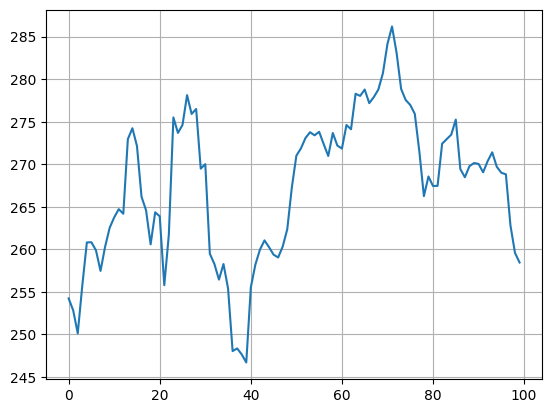

In [35]:
# Plotting time series of closing daily values of AAPL stock 
aapl['close'].plot(grid = True)

<Axes: >

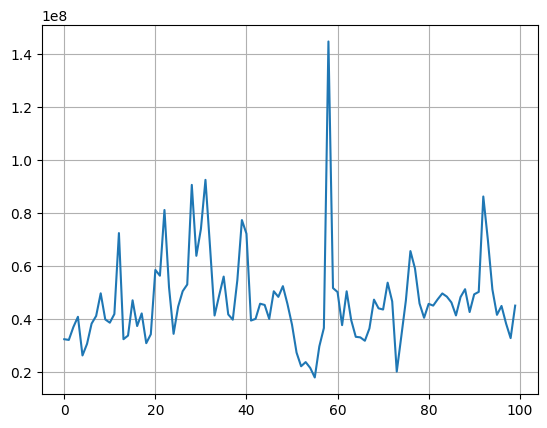

In [36]:
# Plotting time series of volume of AAPL stock traded 
aapl['volume'].plot(grid = True)

0          NaN
1    -0.005562
2    -0.010737
3     0.022299
4     0.019553
        ...   
95   -0.002599
96   -0.000707
97   -0.022535
98   -0.012404
99   -0.004363
Name: close, Length: 100, dtype: float64


<Axes: >

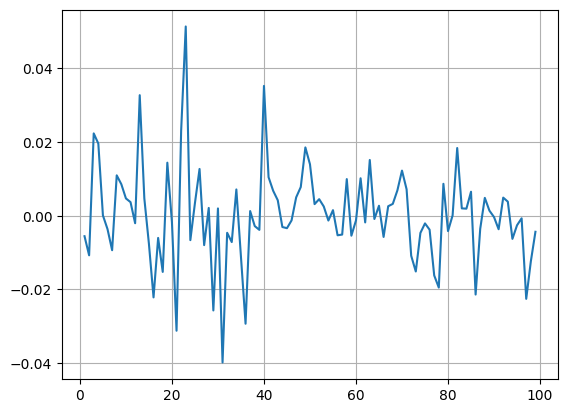

In [37]:
# Calculating and plotting monthly log returns
daily_log_returns_shift = np.log(aapl['close']/aapl['close'].shift(1))
print(daily_log_returns_shift)
daily_log_returns_shift.plot(grid = True)

<Axes: >

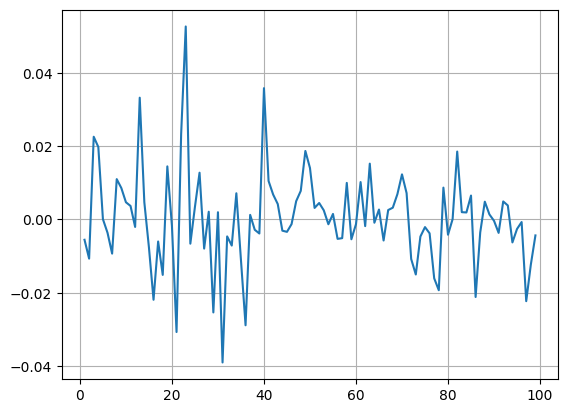

In [38]:
# Calculating actual daily returns 
aapl['Returns'] = aapl['close'].pct_change()
daily_returns = aapl[['Returns']]
aapl['Returns'].plot(grid = True)

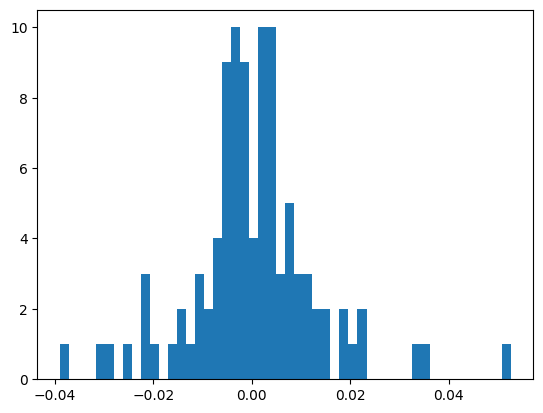

         Returns
count  99.000000
mean    0.000252
std     0.013188
min    -0.038999
25%    -0.005352
50%    -0.000370
75%     0.005744
max     0.052611


In [39]:
# Plotting distribution of returns 

import matplotlib.pyplot as plt
plt.hist(daily_returns, bins = 50)
plt.show()

# Summary statistics of daily returns 

print(daily_returns.describe())

     Returns
0        NaN
1   0.994454
2   0.983834
3   1.006018
4   1.025882
..       ...
95  1.058097
96  1.057350
97  1.033788
98  1.021044
99  1.016599

[100 rows x 1 columns]


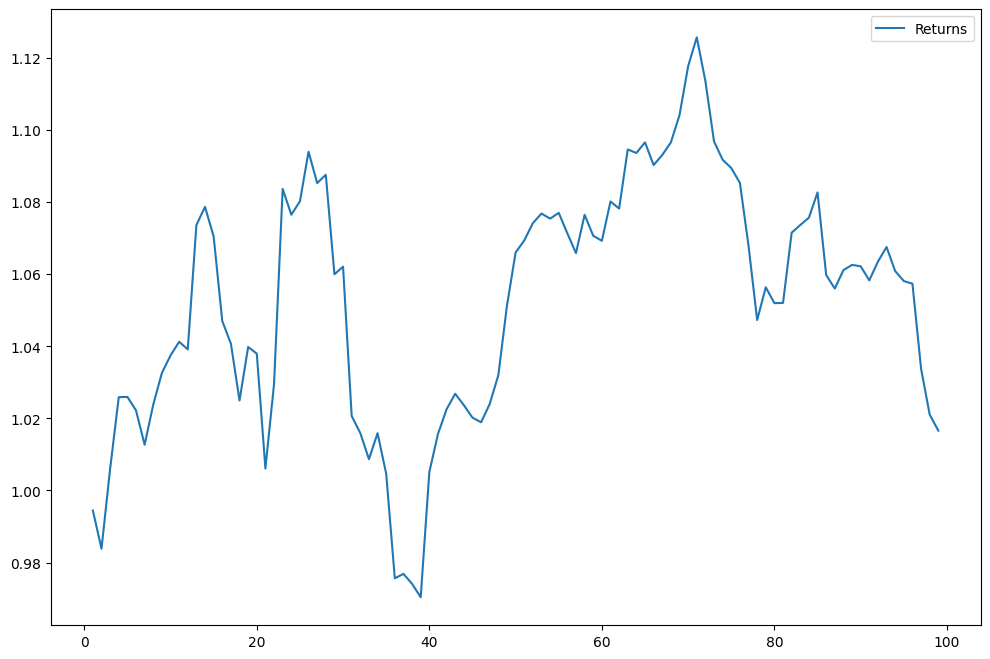

In [40]:
# Calculating cumulative returns 

cum_return = (1 + daily_returns).cumprod()
print(cum_return)

cum_return.plot(figsize = (12,8))
plt.show()

**Moving windows:**

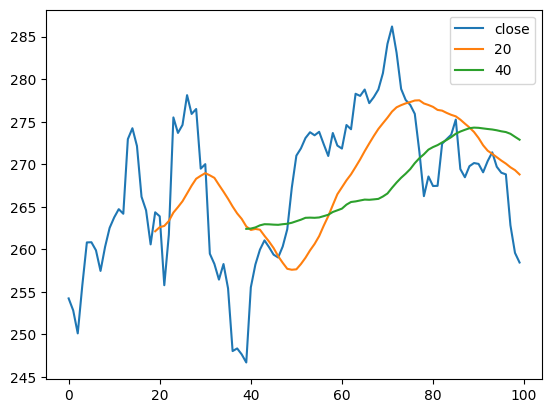

In [47]:
close_px = aapl['close']

# Short moving window rolling mean: 
aapl['20'] = close_px.rolling(window = 20).mean()

# Long moving window rolling mean: 
aapl['40'] = close_px.rolling(window = 40).mean()

# Plotting the closing price with the short and long windows of rolling means: 

aapl[['close', '20', '40']].plot()
plt.show()

In [43]:
aapl

,timestamp,open,high,low,close,volume,Returns,40,150
0,2026-03-17,252.820,255.1299,252.1800,254.23,32342249,NaN,NaN,NaN
1,2026-03-16,252.105,253.8850,249.8800,252.82,32074209,-0.005546,NaN,NaN
2,2026-03-13,255.480,256.3300,249.5200,250.12,36929988,-0.010680,NaN,NaN
3,2026-03-12,258.660,258.9500,254.1800,255.76,40794020,0.022549,NaN,NaN
4,2026-03-11,261.090,262.1300,259.5500,260.81,26218927,0.019745,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,2025-10-28,268.985,269.8900,268.1500,269.00,41534759,-0.002595,273.86925,NaN
96,2025-10-27,264.880,269.1200,264.6501,268.81,44888152,-0.000706,273.78050,NaN
97,2025-10-24,261.190,264.1300,259.1800,262.82,38253717,-0.022283,273.57675,NaN
98,2025-10-23,259.940,260.6200,258.0101,259.58,32754941,-0.012328,273.22450,NaN


**Volatility:**

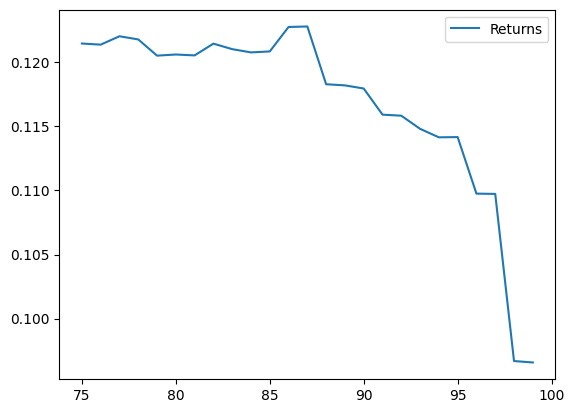

In [50]:
# Calculating volatility: 

min_periods = 75
vol = daily_returns.rolling(min_periods).std() * np.sqrt(min_periods)

# Plotting volatility: 
vol.plot()
plt.show()

**Trading Strategy:** 

In [51]:
short_window = 20
long_window = 40

# Creating a DF called "signals" which includes a column called "signal"
signals = pd.DataFrame(index = aapl.index)
signals['signal'] = 0.0

# Creating a short simple moving average over the short window: 
signals['short_MA'] = aapl['close'].rolling(window = short_window, min_periods = 1, center = False).mean()

# Creating a long simple moving average over the short window: 
signals['long_MA'] = aapl['close'].rolling(window = long_window, min_periods = 1, center = False).mean()

# Creating signals: 
signals['signal'][short_window:] = np.where(signals['short_MA'][short_window:] > signals['long_MA'][short_window:], 1.0, 0.0)

# Trading orders: 
signals['positions'] = signals['signal'].diff()

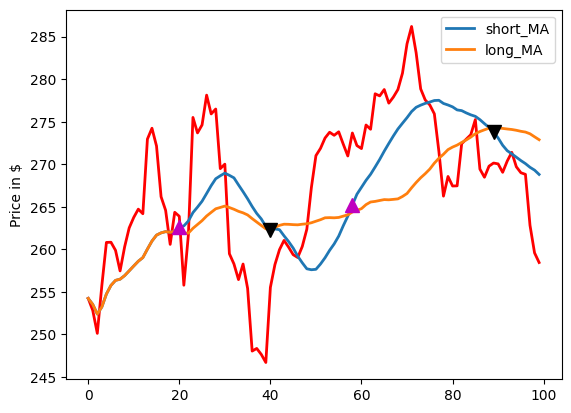

In [53]:
# Plotting the short and long moving averages, as ewll as the buying and selling signals: 

fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel = 'Price in $')

aapl['close'].plot(ax = ax1, color = 'red', lw = 2.)

signals[['short_MA', 'long_MA']].plot(ax = ax1, lw = 2.)

# Plotting buy signals: 
ax1.plot(signals.loc[signals.positions == 1.0].index, signals.short_MA[signals.positions == 1.0], '^', markersize = 10, color = 'm')

# Plotting sell signals: 
ax1.plot(signals.loc[signals.positions == -1.0].index, signals.short_MA[signals.positions == -1.0], 'v', markersize = 10, color = 'k')

plt.show()

**Backtesting the strategy:**

In [54]:
# Setting initial capital: 
initial_capital = float(100000.0)

# Creating a DataFrame: 
positions = pd.DataFrame(index = signals.index).fillna(0.0)

# Starting off with buying 100 Apple shares: 
positions['AAPL'] = 100*signals['signal']   
  
# Initialize the portfolio with value owned   
portfolio = positions.multiply(aapl['close'], axis=0)

# Store the difference in shares owned 
pos_diff = positions.diff()

# Add `holdings` to portfolio
portfolio['holdings'] = (positions.multiply(aapl['close'], axis=0)).sum(axis=1)

# Add `cash` to portfolio
portfolio['cash'] = initial_capital - (pos_diff.multiply(aapl['close'], axis=0)).sum(axis=1).cumsum()   

# Add `total` to portfolio
portfolio['total'] = portfolio['cash'] + portfolio['holdings']

# Add `returns` to portfolio
portfolio['returns'] = portfolio['total'].pct_change()

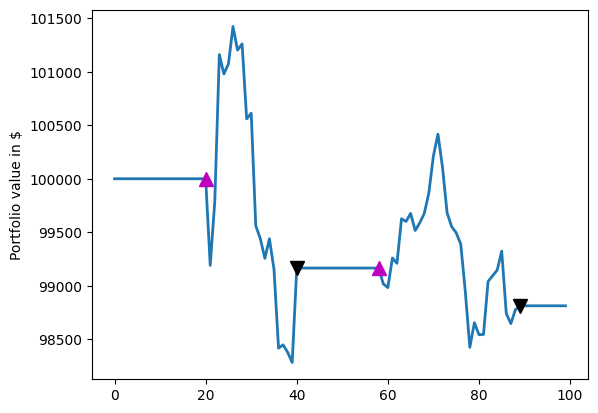

In [55]:
import matplotlib.pyplot as plt

fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel='Portfolio value in $')

# Plot the equity curve in dollars
portfolio['total'].plot(ax=ax1, lw=2.)

# Plot the "buy" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == 1.0].index, 
         portfolio.total[signals.positions == 1.0],
         '^', markersize=10, color='m')

# Plot the "sell" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == -1.0].index, 
         portfolio.total[signals.positions == -1.0],
         'v', markersize=10, color='k')

# Show the plot
plt.show()

It looks like our strategy has performed poorly! We see that our portfolio fell in value (lmao). 

**Evaluating the Moving Average Crossover Strategy:**

Sharpe Ratio: 

In [ ]:
returns = portfolio['returns']

sharpe_ratio = np.sqrt(40) * (returns.mean()/ returns.std())
print(sharpe_ratio)

-0.25362474791715495


Maximum Drawdown: 

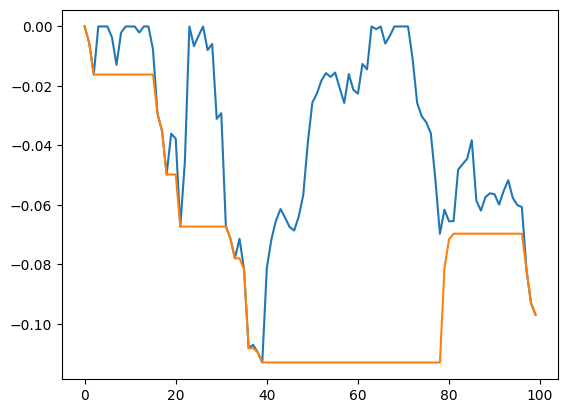

In [61]:
window = 40 

rolling_max = aapl['close'].rolling(window, min_periods = 1).max()
daily_drawdown = aapl['close']/rolling_max - 1

max_daily_drawdown = daily_drawdown.rolling(window, min_periods = 1).min()

daily_drawdown.plot()
max_daily_drawdown.plot()

plt.show()

Compound Annual Growth Rate (CAGR): 

In [66]:
# Number of days in series: 
days = 100 
    # There are 100 rows in the scraped dataset, with one observation per day, indicating that we have 100 days 

# Calculate the CAGR 
cagr = ((((aapl['close'][99]) / aapl['close'][1])) ** (365.0/days)) - 1

# Print CAGR
print(cagr)

0.08370892414435249
